# 01: ISCX VPN-nonVPN Dataset Exploration

**Thesis:** *Impact of Machine-Learning Traffic Classification Errors on Multi-Class Capacity Dimensioning in Multirate Loss Systems*

**Dataset:** ISCX VPN-nonVPN 2016 (Draper-Gil et al., 2016), Scenario B time-based features, 15-second aggregation window.

This notebook loads the raw ARFF data, filters to the 5-class subset used in the thesis,
cleans known data quality issues, and produces summary statistics and visualisations
for Chapter 4.

> Execution record of `01_data_exploration.ipynb` with its outputs. Re-run the source notebook
> from `notebooks/`, not this file.

## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.io.arff import loadarff
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif
from pathlib import Path

%matplotlib inline
sns.set_style('whitegrid')

DATA_DIR = Path('..') / 'data' / 'Scenario B-ARFF'
PROCESSED_DIR = Path('..') / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ARFF_15S = DATA_DIR / 'TimeBasedFeatures-Dataset-15s-AllinOne.arff'

# Working palette for this notebook only (seaborn Set2); the thesis figures use the Okabe-Ito palette in src/figures/style.py
CLASS_ORDER = ['VoIP', 'Chat', 'Browsing', 'FileTransfer', 'Streaming']
CLASS_COLORS = dict(zip(CLASS_ORDER, sns.color_palette('Set2', 5)))

# Bandwidth demands (t_k) in units, from thesis specification
TK_MAP = {'VoIP': 1, 'Chat': 1, 'Browsing': 2, 'FileTransfer': 8, 'Streaming': 15}

print('Setup complete.')

Setup complete.


In [2]:
raw_data, meta = loadarff(ARFF_15S)
df_raw = pd.DataFrame(raw_data)

df_raw['class1'] = df_raw['class1'].str.decode('utf-8')

FEATURE_COLS = [c for c in df_raw.columns if c != 'class1']

print(f'Loaded {ARFF_15S.name}')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns ({len(FEATURE_COLS)} features + 1 label)')
print(f'Feature dtypes: {df_raw[FEATURE_COLS].dtypes.unique()}')
df_raw.head()

Loaded TimeBasedFeatures-Dataset-15s-AllinOne.arff
Shape: 18758 rows x 24 columns (23 features + 1 label)
Feature dtypes: [dtype('float64')]


,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle,class1
0,9368711.0,16.0,4.0,1564818.0,1549373.0,190205.285714,203290.456522,389822.391917,370323.719754,10.353612,...,267600.198443,1871488.0,1.983656e+06,2195089.0,1.832197e+05,1234883.0,1420565.0,1523088.0,161096.539275,CHAT
1,7340238.0,18.0,4.0,1567554.0,1527893.0,165686.977273,186914.846154,317267.548742,304370.651301,11.580006,...,221462.862028,1491627.0,3.572433e+06,5653239.0,2.942704e+06,1131498.0,1324636.0,1517774.0,273138.379008,CHAT
2,4644225.0,29.0,15.0,1270547.0,1079974.0,165865.178571,195302.130435,329473.126261,300492.588227,11.412022,...,217475.425246,1758922.0,1.758922e+06,1758922.0,0.000000e+00,1079974.0,1079974.0,1079974.0,0.000000,CHAT
3,4978735.0,19.0,8.0,2492050.0,2457286.0,239543.250000,276596.388889,612435.304238,628339.573544,8.034169,...,436959.716436,1710925.0,2.382905e+06,3054885.0,9.503232e+05,1346073.0,1894031.5,2441990.0,774930.342317,CHAT
4,11838189.0,19.0,10.0,3094089.0,3093543.0,243766.500000,295954.725000,599721.781709,625632.703972,7.602514,...,436129.639296,1747431.0,2.400446e+06,3240696.0,6.232744e+05,1394455.0,1983227.0,3042717.0,725987.829075,CHAT


## 2. Raw Dataset Overview

In [3]:
# 7-class distribution
raw_counts = df_raw['class1'].value_counts()
raw_pcts = df_raw['class1'].value_counts(normalize=True) * 100

dist_7class = pd.DataFrame({'count': raw_counts, 'percentage': raw_pcts.round(2)})
dist_7class.index.name = 'class'
print('Full 7-class distribution:')
print(dist_7class.to_string())
print(f'\nTotal flows: {len(df_raw)}')

Full 7-class distribution:
           count  percentage
class                       
VOIP        5097       27.17
BROWSING    5000       26.66
FT          2950       15.73
CHAT        2086       11.12
P2P         1928       10.28
STREAMING    957        5.10
MAIL         740        3.94

Total flows: 18758


In [4]:
# Basic statistics for all features
print('Feature summary statistics:')
df_raw[FEATURE_COLS].describe().T

Feature summary statistics:


,count,mean,std,min,25%,50%,75%,max
duration,18758.0,9.791705e+06,1.438458e+07,0.0,334669.000000,1.109263e+07,1.494537e+07,601404954.0
total_fiat,18758.0,6.086783e+05,2.243195e+06,-1.0,7.000000,6.200000e+01,1.645000e+03,37680787.0
total_biat,18758.0,6.267802e+05,2.326442e+06,-1.0,2.000000,2.100000e+01,1.651000e+03,43002377.0
min_fiat,18758.0,3.314204e+06,1.062115e+07,-1.0,25970.500000,2.821430e+05,4.289454e+06,303595747.0
min_biat,18758.0,2.861716e+06,9.652561e+06,-1.0,24542.250000,2.865800e+05,4.265465e+06,600109667.0
max_fiat,18758.0,1.003929e+06,3.141855e+06,0.0,11543.327550,5.104959e+04,5.260302e+05,152000000.0
max_biat,18758.0,9.218250e+05,2.495984e+06,0.0,5626.785609,3.526250e+04,4.843726e+05,43000000.0
mean_fiat,18758.0,8.448286e+05,4.336559e+06,0.0,114.546932,1.164916e+04,6.055940e+05,215000000.0
mean_biat,18758.0,6.133578e+05,2.516395e+06,0.0,0.000000,9.605910e+03,5.340370e+05,98000000.0
flowPktsPerSecond,18758.0,2.073780e+03,1.911571e+04,0.0,2.599190,1.168122e+01,1.006717e+02,1000000.0


In [5]:
# Check for NaN, inf, and -1 sentinel values
nan_counts = df_raw[FEATURE_COLS].isna().sum()
inf_counts = df_raw[FEATURE_COLS].apply(lambda s: np.isinf(s).sum())
neg1_counts = df_raw[FEATURE_COLS].apply(lambda s: (s == -1).sum())

quality_check = pd.DataFrame({
    'NaN': nan_counts,
    'inf': inf_counts,
    'sentinel_-1': neg1_counts
})
# Only show features with at least one issue
issues = quality_check[quality_check.sum(axis=1) > 0]
if len(issues) > 0:
    print(f'{len(issues)} features have quality issues:')
    print(issues.to_string())
else:
    print('No NaN, inf, or -1 sentinel values found.')

print(f'\nTotal -1 sentinel values across all features: {neg1_counts.sum()}')

10 features have quality issues:
             NaN  inf  sentinel_-1
total_fiat     0    0         2641
total_biat     0    0         3637
min_fiat       0    0         2641
min_biat       0    0         3637
min_flowiat    0    0          581
max_flowiat    0    0          532
min_active     0    0        11355
max_active     0    0        11355
min_idle       0    0        11355
max_idle       0    0        11355

Total -1 sentinel values across all features: 59089


## 3. Five-Class Filtering and Mapping

Following the FlowPic/DISTILLER convention, the thesis uses 5 of the 7 original classes.
MAIL and P2P are dropped: MAIL has too few samples for reliable classification,
and P2P is not relevant to the IPTV/OTT service scenario modelled in the thesis.

In [6]:
# Classes to keep (original ARFF labels)
KEEP_CLASSES = ['VOIP', 'CHAT', 'BROWSING', 'FT', 'STREAMING']

# Mapping from ARFF labels to thesis convention
LABEL_MAP = {
    'VOIP': 'VoIP',
    'CHAT': 'Chat',
    'BROWSING': 'Browsing',
    'FT': 'FileTransfer',
    'STREAMING': 'Streaming'
}

# Filter
mask = df_raw['class1'].isin(KEEP_CLASSES)
df = df_raw[mask].copy()
dropped = len(df_raw) - len(df)

# Rename
df['class1'] = df['class1'].map(LABEL_MAP)

print(f'Kept {len(df)} flows, dropped {dropped} (MAIL: {raw_counts.get("MAIL", 0)}, P2P: {raw_counts.get("P2P", 0)})')
print(f'Remaining fraction: {len(df)/len(df_raw)*100:.1f}%')

Kept 16090 flows, dropped 2668 (MAIL: 740, P2P: 1928)
Remaining fraction: 85.8%


In [7]:
# 5-class distribution
class5_counts = df['class1'].value_counts().reindex(CLASS_ORDER)
class5_pcts = (class5_counts / class5_counts.sum() * 100).round(2)

dist_5class = pd.DataFrame({'count': class5_counts, 'percentage': class5_pcts})
dist_5class.index.name = 'class'
print('5-class distribution:')
print(dist_5class.to_string())
print(f'\nTotal flows: {class5_counts.sum()}')

5-class distribution:
              count  percentage
class                          
VoIP           5097       31.68
Chat           2086       12.96
Browsing       5000       31.08
FileTransfer   2950       18.33
Streaming       957        5.95

Total flows: 16090


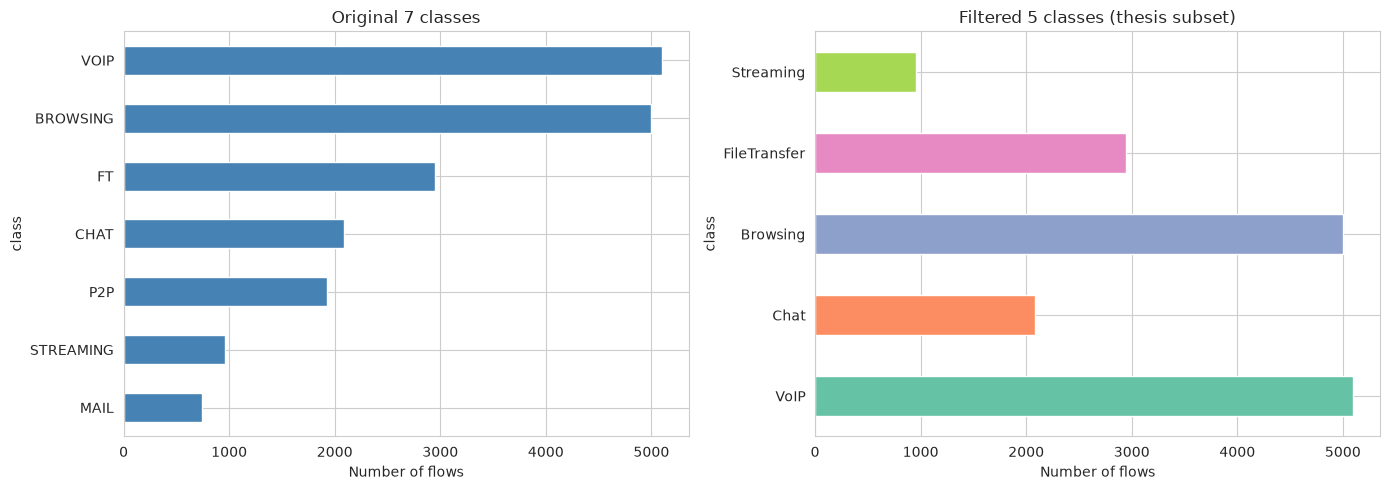

In [8]:
# Side-by-side comparison: 7-class vs 5-class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 7-class
raw_counts.sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Original 7 classes')
axes[0].set_xlabel('Number of flows')

# 5-class
class5_counts.plot.barh(ax=axes[1], color=[CLASS_COLORS[c] for c in CLASS_ORDER])
axes[1].set_title('Filtered 5 classes (thesis subset)')
axes[1].set_xlabel('Number of flows')

plt.tight_layout()
plt.show()

## 4. Data Quality Analysis

Known issues in the ISCX VPN-nonVPN dataset:

1. **Sentinel values (`-1`):** Ten features use `-1` as a sentinel for unidirectional flows
   or inactive periods. This affects IAT features (`total_fiat`, `min_fiat`, `total_biat`,
   `min_biat`, `min_flowiat`, `max_flowiat`) and active/idle features (`min_active`,
   `max_active`, `min_idle`, `max_idle`). These are replaced with `0`
   because such flows contribute zero time in the missing direction/period.

2. **Extreme outliers:** Short-duration flows can produce very large `flowBytesPerSecond`
   and `flowPktsPerSecond` values. Every feature is clipped at its own 99.9th percentile.

In [9]:
# Count -1 sentinel values per feature in the 5-class subset
neg1_per_feat = df[FEATURE_COLS].apply(lambda s: (s == -1).sum())
affected = neg1_per_feat[neg1_per_feat > 0]

print(f'Features with -1 sentinel values ({len(affected)}/{len(FEATURE_COLS)}):')
print(affected.to_string())
print(f'\nTotal -1 values in 5-class subset: {affected.sum()}')

Features with -1 sentinel values (10/23):
total_fiat     1373
total_biat     1909
min_fiat       1373
min_biat       1909
min_flowiat     299
max_flowiat     256
min_active     9127
max_active     9127
min_idle       9127
max_idle       9127

Total -1 values in 5-class subset: 43627


In [10]:
# Replace -1 sentinels with 0
sentinel_cols = affected.index.tolist()
for col in sentinel_cols:
    df[col] = df[col].replace(-1, 0)

# Verify
remaining_neg1 = df[FEATURE_COLS].apply(lambda s: (s == -1).sum()).sum()
print(f'Remaining -1 values after replacement: {remaining_neg1}')

Remaining -1 values after replacement: 0


In [11]:
# Check for infinities and very large values before clipping
inf_count = df[FEATURE_COLS].apply(lambda s: np.isinf(s).sum()).sum()
print(f'Infinite values: {inf_count}')

# Distribution of flowBytesPerSecond and flowPktsPerSecond before clipping
rate_features = ['flowBytesPerSecond', 'flowPktsPerSecond']
print('\nBefore clipping:')
print(df[rate_features].describe().to_string())

Infinite values: 0

Before clipping:
       flowBytesPerSecond  flowPktsPerSecond
count        1.609000e+04       16090.000000
mean         4.541975e+05        1660.057433
std          9.551780e+06       19570.240710
min          0.000000e+00           0.000000
25%          3.886597e+02           2.415138
50%          2.745539e+03          11.518316
75%          1.274310e+04         100.495858
max          6.170000e+08     1000000.000000


In [12]:
# Clip all numeric features at the 99.9th percentile
clip_thresholds = {}
for col in FEATURE_COLS:
    p999 = df[col].quantile(0.999)
    n_clipped = (df[col] > p999).sum()
    if n_clipped > 0:
        clip_thresholds[col] = {'threshold': p999, 'n_clipped': n_clipped}
    df[col] = df[col].clip(upper=p999)

print(f'Features clipped at 99.9th percentile ({len(clip_thresholds)} affected):')
clip_df = pd.DataFrame(clip_thresholds).T
print(clip_df.to_string())

print('\nAfter clipping:')
print(df[rate_features].describe().to_string())

Features clipped at 99.9th percentile (23 affected):
                       threshold  n_clipped
duration            1.459800e+08       17.0
total_fiat          1.415031e+07       17.0
total_biat          1.485332e+07       17.0
min_fiat            1.263936e+08       17.0
min_biat            1.214238e+08       17.0
max_fiat            2.750000e+07        9.0
max_biat            1.558220e+07       17.0
mean_fiat           5.490000e+07       14.0
mean_biat           4.385550e+07       17.0
flowPktsPerSecond   2.857143e+05       14.0
flowBytesPerSecond  4.547330e+07       17.0
min_flowiat         6.381875e+06       17.0
max_flowiat         1.441516e+08       17.0
mean_flowiat        1.370000e+07       16.0
std_flowiat         3.890000e+07       14.0
min_active          1.423705e+08       17.0
mean_active         1.425550e+08       17.0
max_active          1.442463e+08       17.0
std_active          4.059110e+07       17.0
min_idle            1.418280e+08       17.0
mean_idle           1.4

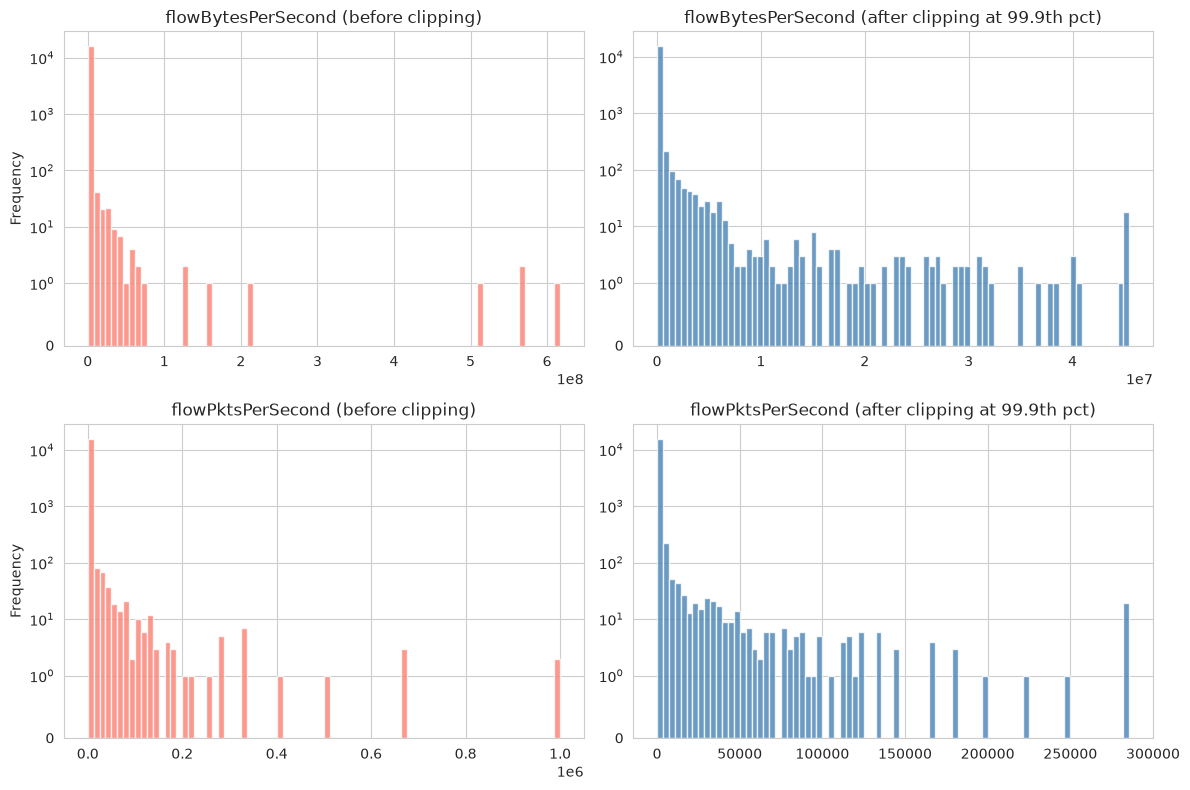

In [13]:
# Before/after comparison for rate features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, feat in enumerate(rate_features):
    # Before (from raw filtered data)
    raw_vals = df_raw.loc[mask, feat]
    axes[i, 0].hist(raw_vals, bins=80, color='salmon', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{feat} (before clipping)')
    axes[i, 0].set_ylabel('Frequency')
    
    # After
    axes[i, 1].hist(df[feat], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_yscale('symlog', linthresh=1)
    axes[i, 1].set_yscale('symlog', linthresh=1)
    axes[i, 1].set_title(f'{feat} (after clipping at 99.9th pct)')

plt.tight_layout()
plt.show()

In [14]:
# Final quality check
nan_final = df[FEATURE_COLS].isna().sum().sum()
inf_final = df[FEATURE_COLS].apply(lambda s: np.isinf(s).sum()).sum()
neg1_final = df[FEATURE_COLS].apply(lambda s: (s == -1).sum()).sum()

print('Final data quality check:')
print(f'  NaN values:  {nan_final}')
print(f'  Inf values:  {inf_final}')
print(f'  -1 sentinels: {neg1_final}')
print(f'  Shape: {df.shape}')

Final data quality check:
  NaN values:  0
  Inf values:  0
  -1 sentinels: 0
  Shape: (16090, 24)


## 5. Feature Distributions

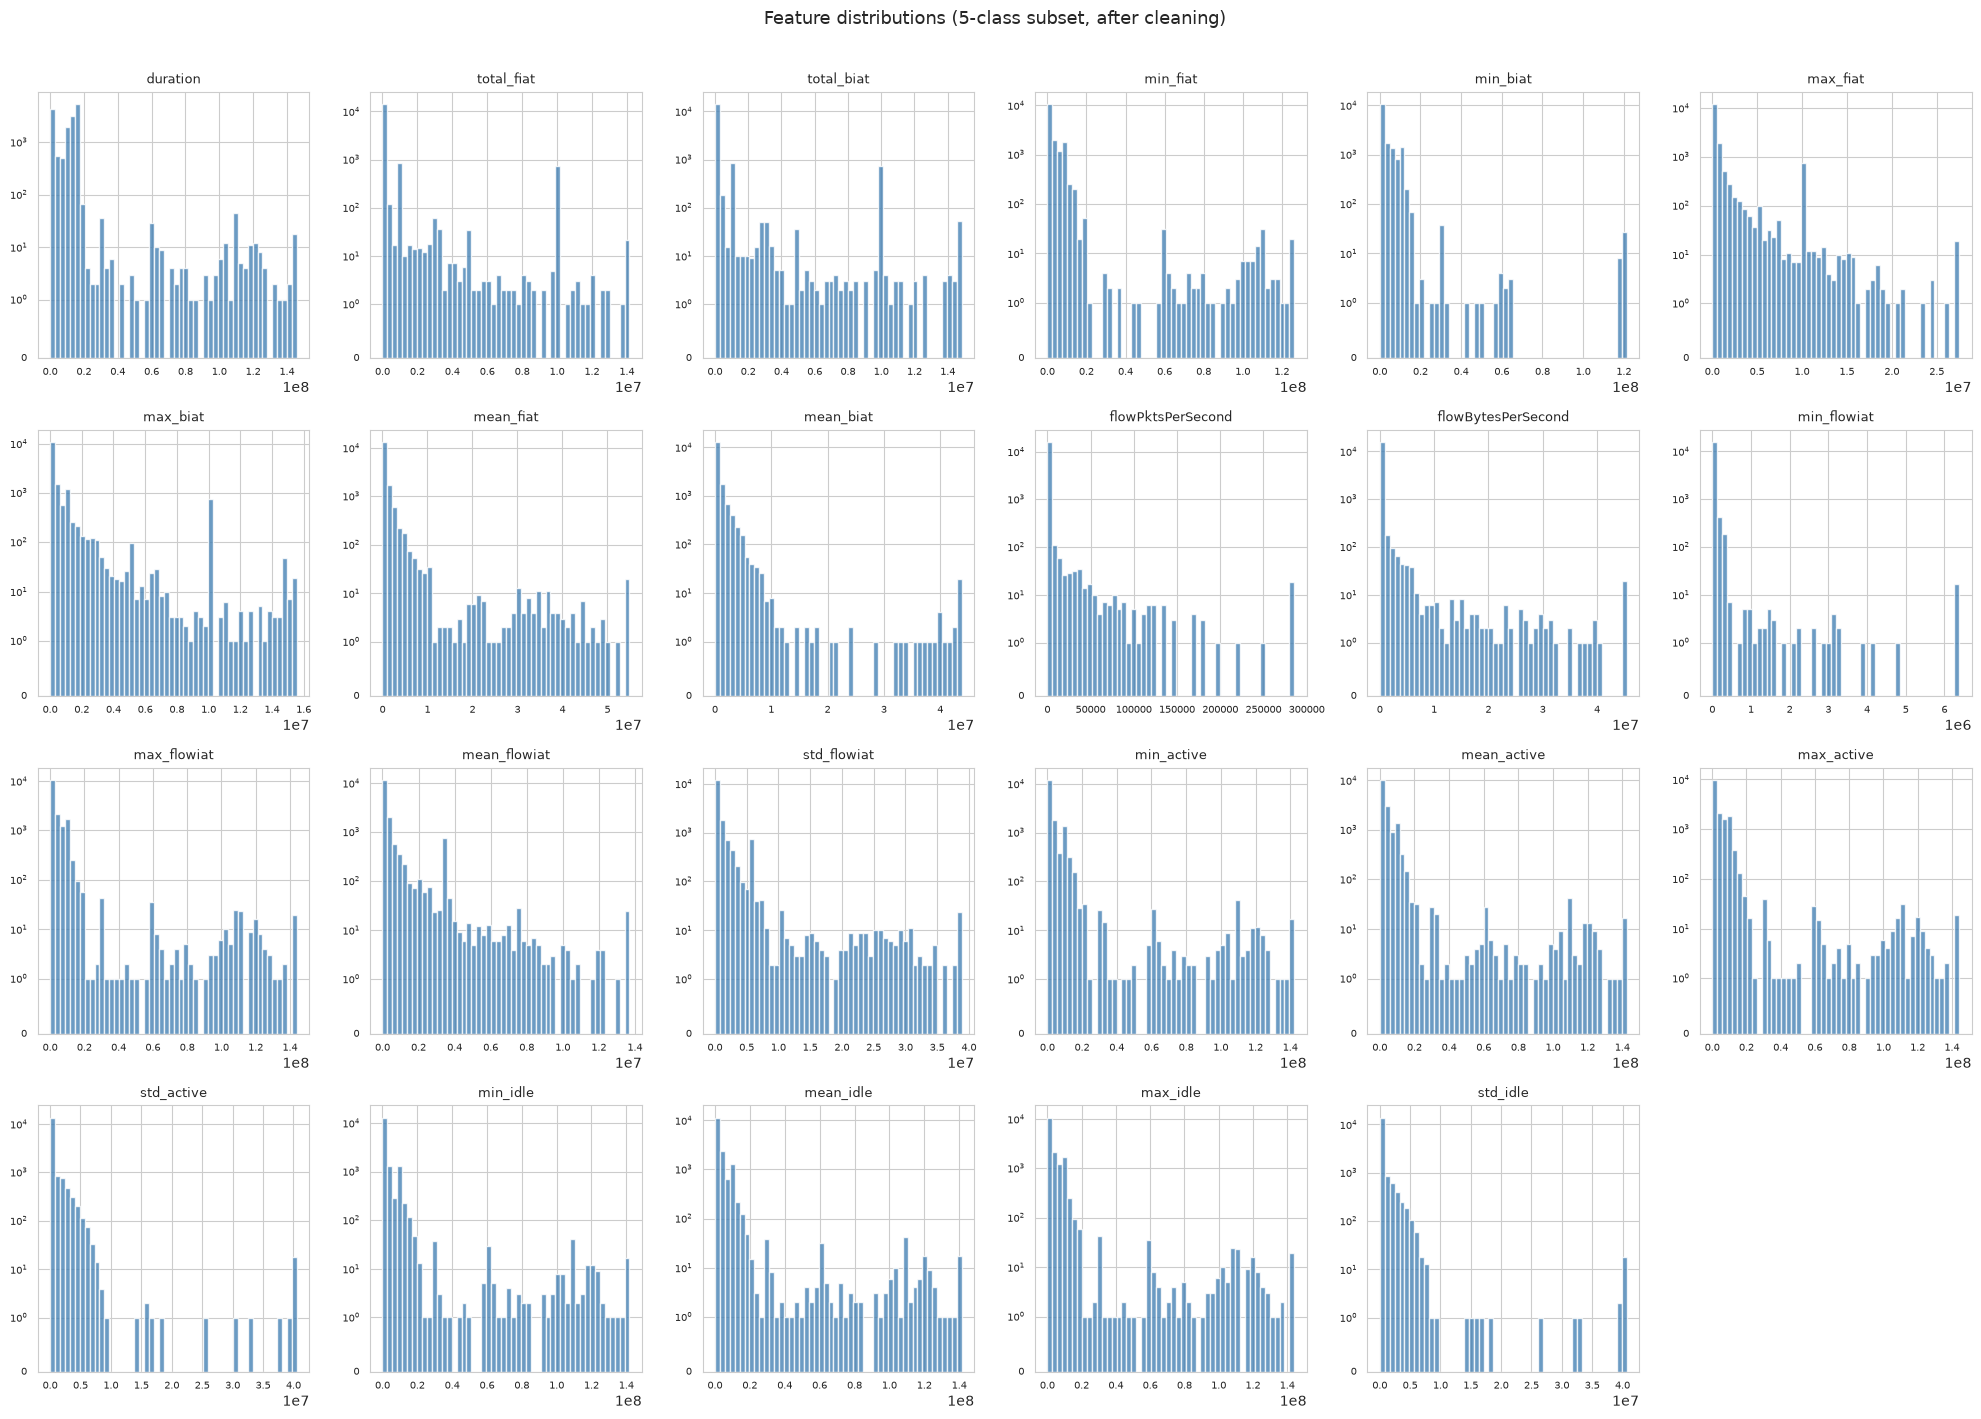

In [15]:
# 4x6 grid, 24 subplots, the last one hidden
fig, axes = plt.subplots(4, 6, figsize=(20, 14))
axes_flat = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes_flat[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    # log-y to compress the long tail; many features are heavy-tailed (durations, byte counts)
    axes_flat[i].set_yscale('symlog', linthresh=1)
    axes_flat[i].set_title(col, fontsize=9)
    axes_flat[i].tick_params(labelsize=7)

axes_flat[-1].set_visible(False)

fig.suptitle('Feature distributions (5-class subset, after cleaning)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

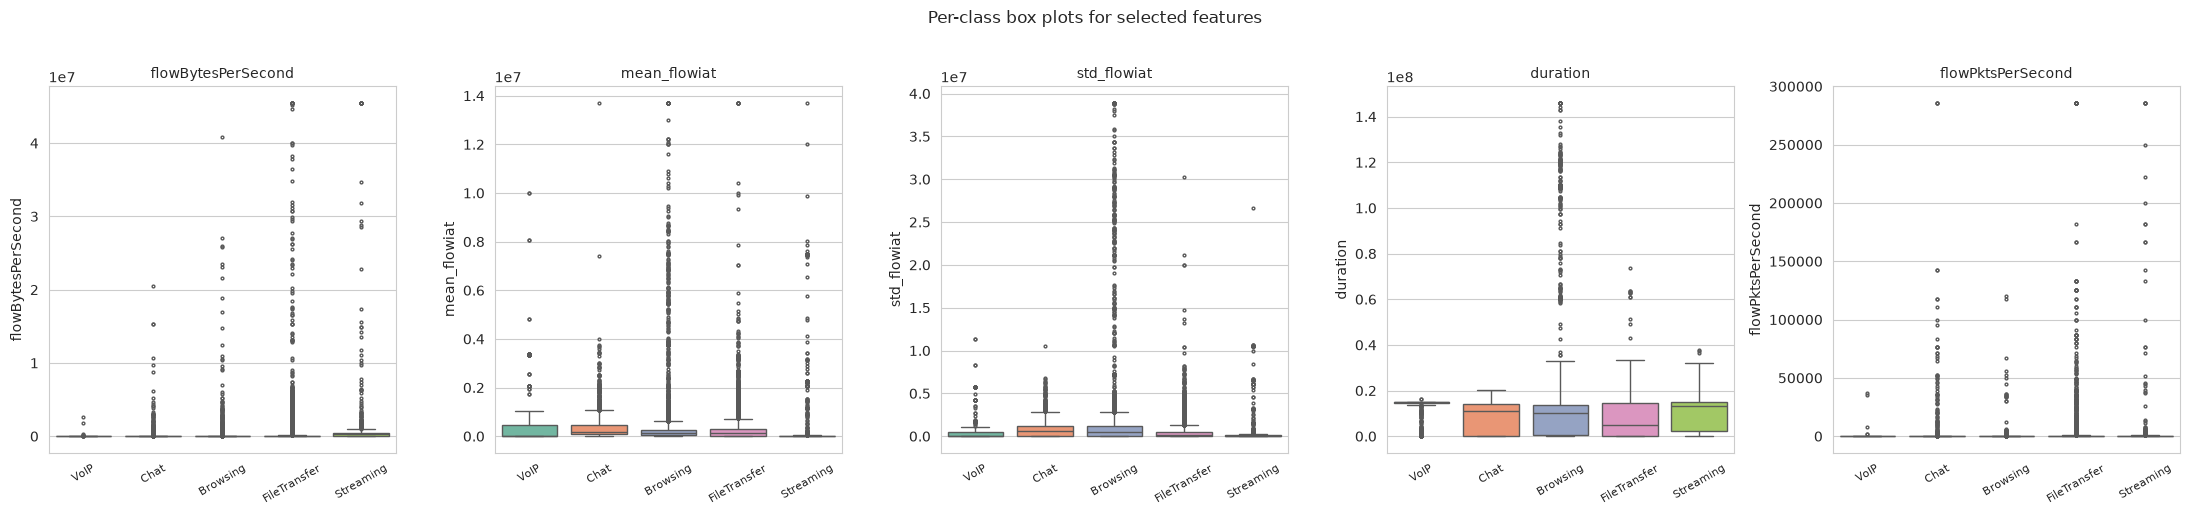

In [16]:
# Box plots by class for selected features
box_features = ['flowBytesPerSecond', 'mean_flowiat', 'std_flowiat', 'duration', 'flowPktsPerSecond']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, feat in enumerate(box_features):
    sns.boxplot(
        data=df, x='class1', y=feat, order=CLASS_ORDER,
        palette=CLASS_COLORS, ax=axes[i], fliersize=2
    )
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

fig.suptitle('Per-class box plots for selected features', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

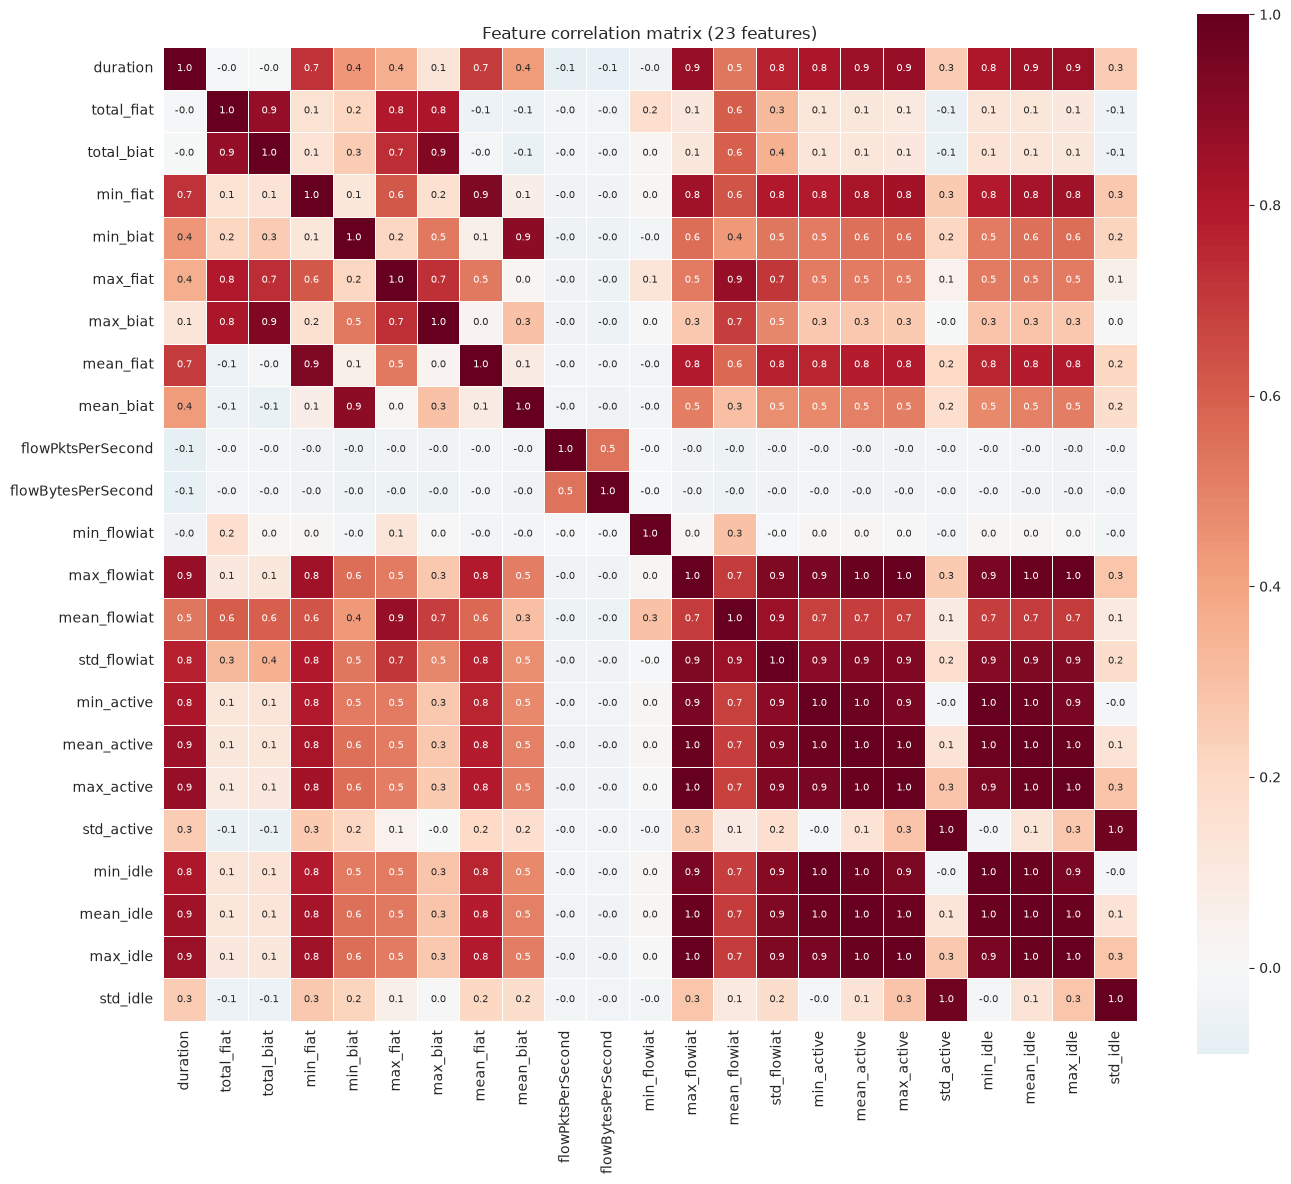

In [17]:
# Correlation heatmap (23x23)
corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Feature correlation matrix (23 features)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Per-Class Feature Analysis

In [18]:
# Per-class mean and standard deviation for all features
class_means = df.groupby('class1')[FEATURE_COLS].mean().reindex(CLASS_ORDER)
class_stds = df.groupby('class1')[FEATURE_COLS].std().reindex(CLASS_ORDER)

print('Per-class feature means:')
class_means.T

Per-class feature means:


class1,VoIP,Chat,Browsing,FileTransfer,Streaming
duration,1.384060e+07,8.385207e+06,1.108423e+07,6.902842e+06,1.083853e+07
total_fiat,1.625908e+06,2.166969e+05,2.250386e+04,3.440271e+05,1.668377e+05
total_biat,1.625541e+06,2.207488e+05,1.397399e+05,2.785938e+05,2.624154e+05
min_fiat,1.707043e+06,3.390427e+06,6.628434e+06,2.260302e+06,2.461771e+06
min_biat,1.721495e+06,3.324492e+06,4.923348e+06,2.044826e+06,2.703443e+06
max_fiat,1.648145e+06,8.287190e+05,8.135143e+05,7.653179e+05,4.075193e+05
max_biat,1.654911e+06,8.216273e+05,6.074204e+05,7.422878e+05,2.952382e+05
mean_fiat,2.742986e+04,1.022256e+06,2.009056e+06,6.783961e+05,5.060464e+05
mean_biat,3.156171e+04,9.951885e+05,1.268428e+06,6.829350e+05,1.424313e+05
flowPktsPerSecond,8.326100e+01,1.791858e+03,2.431559e+02,4.832222e+03,4.016678e+03


In [19]:
# ANOVA F-statistic to identify most discriminative features
X = df[FEATURE_COLS].values
y = df['class1'].values

f_scores, p_values = f_classif(X, y)

anova_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values('F_score', ascending=False)

print('ANOVA F-statistics (all features, sorted by discriminative power):')
print(anova_df.to_string(index=False))

ANOVA F-statistics (all features, sorted by discriminative power):
           feature    F_score       p_value
        total_fiat 424.404651  0.000000e+00
        total_biat 350.173770 1.492495e-289
        max_active 238.043020 6.034176e-199
          max_idle 226.261017 2.722621e-189
       max_flowiat 220.272849 2.247200e-184
        std_active 219.798539 5.512691e-184
         mean_biat 219.287191 1.450654e-183
          std_idle 199.575486 2.492407e-167
         mean_fiat 195.619987 4.604052e-164
       mean_active 192.543401 1.606356e-161
         mean_idle 184.808688 4.037153e-155
          min_fiat 180.052768 3.523232e-151
          duration 179.967479 4.146216e-151
          min_biat 161.539026 8.463555e-136
          max_biat 157.873173 9.560637e-133
        min_active 151.409447 2.341397e-127
          min_idle 147.712361 2.852700e-124
flowBytesPerSecond 114.440384  2.167058e-96
          max_fiat 100.553250  1.070477e-84
 flowPktsPerSecond  83.895835  1.250804e-70
       st

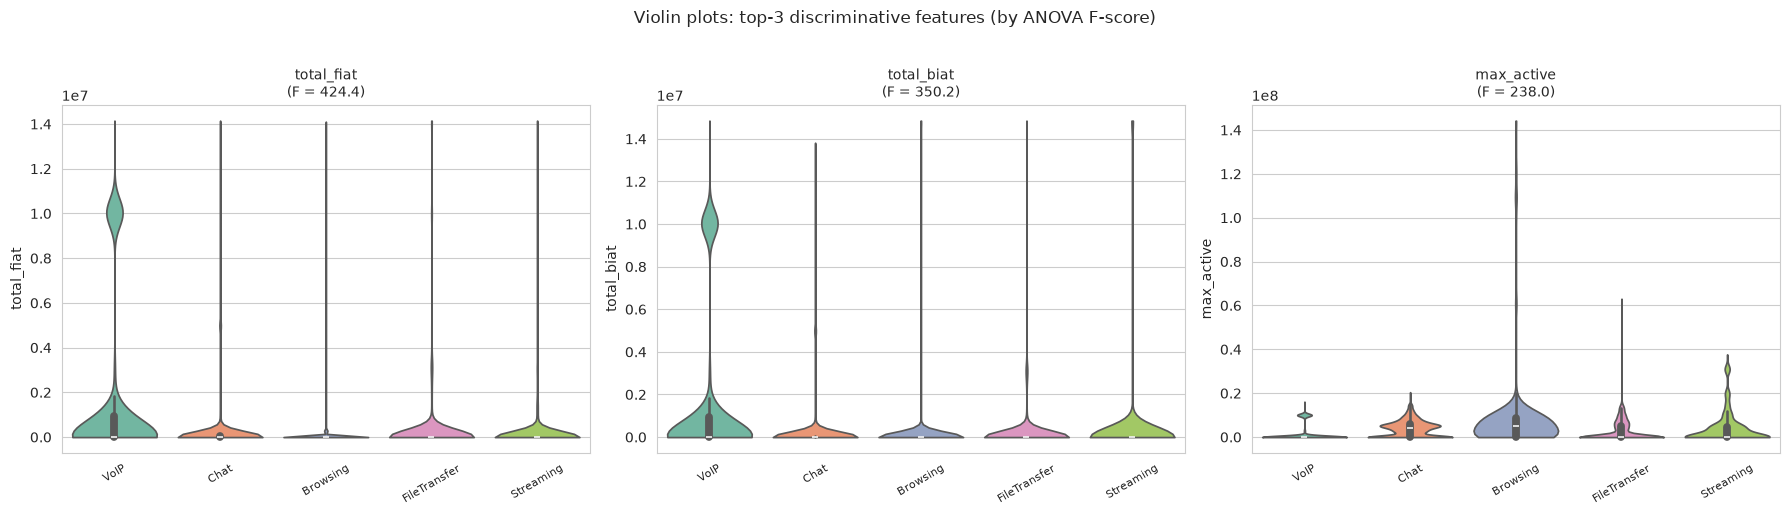

In [20]:
# Violin plots for the top-3 most discriminative features
top3 = anova_df.head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3):
    sns.violinplot(
        data=df, x='class1', y=feat, order=CLASS_ORDER,
        palette=CLASS_COLORS, ax=axes[i], inner='box', cut=0
    )
    f_val = anova_df.loc[anova_df['feature'] == feat, 'F_score'].iloc[0]
    axes[i].set_title(f'{feat}\n(F = {f_val:.1f})', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

fig.suptitle('Violin plots: top-3 discriminative features (by ANOVA F-score)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary Statistics

Tables and mappings used in Chapter 4.

In [21]:
# Summary table for Ch.4
summary = pd.DataFrame({
    'count': class5_counts,
    'percentage': class5_pcts,
    'mean_flowBytesPerSecond': df.groupby('class1')['flowBytesPerSecond'].mean().reindex(CLASS_ORDER).round(1),
    'mean_duration': df.groupby('class1')['duration'].mean().reindex(CLASS_ORDER).round(1)
})
summary.index.name = 'class'

print(f'Total flows (5-class): {class5_counts.sum()}')
print()
print(summary.to_string())

Total flows (5-class): 16090

              count  percentage  mean_flowBytesPerSecond  mean_duration
class                                                                  
VoIP           5097       31.68                   9287.9     13840596.4
Chat           2086       12.96                 101563.7      8385207.2
Browsing       5000       31.08                 122313.0     11084225.5
FileTransfer   2950       18.33                 905812.8      6902842.1
Streaming       957        5.95                1181995.7     10838533.7


In [22]:
# 5-class mapping table with bandwidth demands (t_k)
mapping_table = pd.DataFrame({
    'ARFF_label': ['VOIP', 'CHAT', 'BROWSING', 'FT', 'STREAMING'],
    'thesis_label': CLASS_ORDER,
    't_k (bandwidth units)': [TK_MAP[c] for c in CLASS_ORDER]
})
print('Class mapping with bandwidth demands (t_k):')
print(mapping_table.to_string(index=False))

Class mapping with bandwidth demands (t_k):
ARFF_label thesis_label  t_k (bandwidth units)
      VOIP         VoIP                      1
      CHAT         Chat                      1
  BROWSING     Browsing                      2
        FT FileTransfer                      8
 STREAMING    Streaming                     15


In [23]:
# Save cleaned DataFrame
output_path = PROCESSED_DIR / 'iscx_5class_15s_clean.csv'
df.to_csv(output_path, index=False)
print(f'Saved cleaned data to {output_path}')
print(f'Shape: {df.shape}')

Saved cleaned data to ../data/processed/iscx_5class_15s_clean.csv
Shape: (16090, 24)


## 8. Comparison Across Time Windows (Optional)

The ISCX VPN-nonVPN Scenario B data is provided at four aggregation windows:
15 s, 30 s, 60 s, and 120 s. The 15 s window was chosen for the thesis because
it yields the most flows and is the standard interval used in FlowPic and DISTILLER.

In [24]:
# Note: some ARFF files (e.g. 60s) contain malformed rows that scipy cannot parse. These are skipped with a warning.
windows = ['15s', '30s', '60s', '120s']
window_stats = []

for w in windows:
    path = DATA_DIR / f'TimeBasedFeatures-Dataset-{w}-AllinOne.arff'
    try:
        data_w, _ = loadarff(path)
    except ValueError as e:
        print(f'WARNING: skipping {w} window (ARFF parse error: {e})')
        continue
    df_w = pd.DataFrame(data_w)
    df_w['class1'] = df_w['class1'].str.decode('utf-8')
    
    # Filter to 5 classes
    df_w = df_w[df_w['class1'].isin(KEEP_CLASSES)].copy()
    df_w['class1'] = df_w['class1'].map(LABEL_MAP)
    
    per_class = df_w['class1'].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
    stats = {
        'window': w,
        'total_flows': len(df_w),
    }
    for c in CLASS_ORDER:
        stats[c] = per_class.get(c, 0)
    window_stats.append(stats)

tw_df = pd.DataFrame(window_stats).set_index('window')
print('Flow counts by time window and class (5-class subset):')
print(tw_df.to_string())

Flow counts by time window and class (5-class subset):
        total_flows  VoIP  Chat  Browsing  FileTransfer  Streaming
window                                                            
15s           16090  5097  2086      5000          2950        957
30s           11871  2737  1375      5000          2119        640
120s           8062   778   591      5000          1340        353


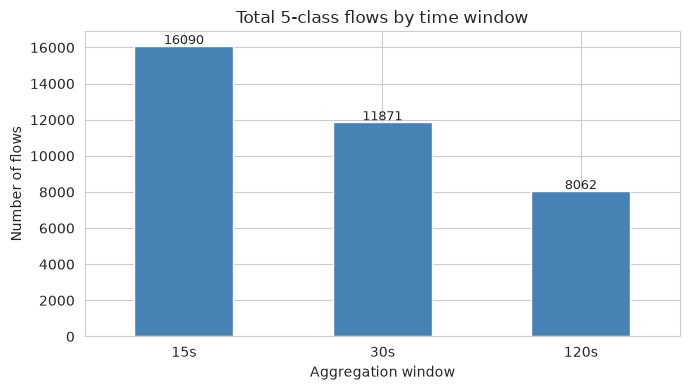

In [25]:
# Visual comparison of total flows by window
fig, ax = plt.subplots(figsize=(7, 4))
tw_df['total_flows'].plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_ylabel('Number of flows')
ax.set_xlabel('Aggregation window')
ax.set_title('Total 5-class flows by time window')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(tw_df['total_flows']):
    ax.text(i, v + 100, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Next step:** `02_classifiers.ipynb` trains the XGBoost and MLP classifiers on the
cleaned 5-class dataset produced here and writes the confusion-matrix archive that
the analytical chapters read.